# 🏎️ Formula One Simulator — Initial EDA

This notebook performs the first exploratory analysis for the Formula One Simulator Datathon project.

### Goals

1. Understand the structure of the supplied datasets.
2. Check missing values and duplicate rows.
3. Inspect driver, constructor, race, and circuit coverage.
4. Explore the relationship between qualifying and race finishing position.
5. Create simple features that may later be useful for predictive modeling.
6. Identify potential leakage risks before building models.

> **Important:** This is an exploratory notebook, not the final modeling pipeline.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATA_DIR = Path("../data/raw")


## 1. Discover the available datasets

In [2]:
csv_files = sorted(DATA_DIR.glob("*.csv"))

print(f"Found {len(csv_files)} CSV files:")
for file in csv_files:
    print(" -", file.name)


Found 6 CSV files:
 - f1_2024_constructor_standings.csv
 - f1_2024_driver_standings.csv
 - f1_2024_race_results.csv
 - f1_circuits_metadata.csv
 - f1_historical_drivers.csv
 - f1_qualifying_results_2024.csv


In [3]:
datasets = {}

for file in csv_files:
    datasets[file.stem] = pd.read_csv(file)

dataset_summary = pd.DataFrame(
    [
        {
            "dataset": name,
            "rows": df.shape[0],
            "columns": df.shape[1],
            "missing_values": int(df.isna().sum().sum()),
            "duplicate_rows": int(df.duplicated().sum()),
        }
        for name, df in datasets.items()
    ]
).sort_values("dataset")

dataset_summary


,dataset,rows,columns,missing_values,duplicate_rows
0,f1_2024_constructor_standings,240,13,0,0
1,f1_2024_driver_standings,480,13,0,0
2,f1_2024_race_results,480,16,0,0
3,f1_circuits_metadata,24,14,0,0
4,f1_historical_drivers,30,16,0,0
5,f1_qualifying_results_2024,480,14,360,0


### Initial data inventory

The repository currently contains race results, qualifying results, driver standings, constructor standings, circuit metadata, and historical driver metadata.

A useful first check is whether missingness represents a true data-quality problem or is structurally expected. For example, Q2 and Q3 times will naturally be missing for drivers eliminated earlier in qualifying.


## 2. Inspect schemas and sample rows

In [4]:
for name, df in datasets.items():
    print("\n" + "=" * 100)
    print(name)
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    display(df.head(3))



f1_2024_constructor_standings
Shape: (240, 13)
Columns: ['race_round', 'position', 'constructor', 'engine', 'team_principal', 'driver_lineup', 'total_points', 'wins', 'podiums', 'pole_positions', 'fastest_laps', 'dnfs', 'races_entered']


,race_round,position,constructor,engine,team_principal,driver_lineup,total_points,wins,podiums,pole_positions,fastest_laps,dnfs,races_entered
0,1,1,Red Bull Racing,Honda RBPT,Christian Horner,Max Verstappen / Sergio Perez,37,1,1,1,1,0,2
1,1,2,Mercedes,Mercedes,Toto Wolff,Lewis Hamilton / George Russell,28,0,1,0,0,0,2
2,1,3,Ferrari,Ferrari,Frederic Vasseur,Carlos Sainz / Charles Leclerc,23,0,1,0,0,0,2



f1_2024_driver_standings
Shape: (480, 13)
Columns: ['race_round', 'position', 'driver_name', 'team', 'nationality', 'total_points', 'wins', 'podiums', 'pole_positions', 'fastest_laps', 'dnfs', 'races_completed', 'points_per_race']


,race_round,position,driver_name,team,nationality,total_points,wins,podiums,pole_positions,fastest_laps,dnfs,races_completed,points_per_race
0,1,1,Max Verstappen,Red Bull Racing,NED,25,1,1,1,0,0,1,25.0
1,1,2,Lewis Hamilton,Mercedes,GBR,18,0,1,0,0,0,1,18.0
2,1,3,Carlos Sainz,Ferrari,ESP,15,0,1,0,0,0,1,15.0



f1_2024_race_results
Shape: (480, 16)
Columns: ['race_id', 'race_name', 'circuit', 'city', 'country', 'circuit_length_km', 'total_laps', 'position', 'driver_name', 'team', 'nationality', 'car_number', 'race_time', 'points', 'fastest_lap', 'pole_position']


...

,circuit_name,city,country,circuit_length_km,total_laps,number_of_turns,lap_record,lap_record_holder,lap_record_year,drs_zones,first_f1_race,circuit_type,elevation_change_m,race_distance_km
0,Bahrain International Circuit,Sakhir,Bahrain,5.412,57,15,1:31.447,Lewis Hamilton,2020,3,2004,Permanent Circuit,44,308.48
1,Jeddah Corniche Circuit,Jeddah,Saudi Arabia,6.174,50,27,1:30.734,Lewis Hamilton,2021,3,2021,Permanent Circuit,20,308.70
2,Albert Park Circuit,Melbourne,Australia,5.278,58,16,1:20.260,Charles Leclerc,2022,2,1996,Permanent Circuit,51,306.12



f1_historical_drivers
Shape: (30, 16)
Columns: ['driver_name', 'nationality', 'last_team', 'birth_year', 'debut_year', 'last_active_year', 'career_length_years', 'race_wins', 'pole_positions', 'podiums', 'fastest_laps', 'championships', 'estimated_race_starts', 'win_rate_percent', 'podium_rate_percent', 'career_status']


,driver_name,nationality,last_team,birth_year,debut_year,last_active_year,career_length_years,race_wins,pole_positions,podiums,fastest_laps,championships,estimated_race_starts,win_rate_percent,podium_rate_percent,career_status
0,Lewis Hamilton,GBR,Mercedes,1983,2007,2024,18,103,104,191,62,59,360,28.61,53.06,Active
1,Michael Schumacher,GER,Ferrari,1969,1991,2012,22,91,68,155,68,77,400,22.75,38.75,Retired
2,Sebastian Vettel,GER,Red Bull Racing,1987,2007,2022,16,53,57,122,57,38,320,16.56,38.12,Retired



f1_qualifying_results_2024
Shape: (480, 14)
Columns: ['race_id', 'race_name', 'circuit', 'qualifying_position', 'driver_name', 'team', 'nationality', 'car_number', 'q1_time', 'q2_time', 'q3_time', 'best_time', 'gap_to_pole', 'eliminated_in']


,race_id,race_name,circuit,qualifying_position,driver_name,team,nationality,car_number,q1_time,q2_time,q3_time,best_time,gap_to_pole,eliminated_in
0,1,Bahrain Grand Prix,Bahrain International Circuit,1,Lewis Hamilton,Mercedes,GBR,44,1:40.335,1:39.244,1:39.103,1:39.103,Pole,Q3
1,1,Bahrain Grand Prix,Bahrain International Circuit,2,Charles Leclerc,Ferrari,MON,16,1:39.750,1:40.523,1:39.913,1:39.913,+0.913,Q3
2,1,Bahrain Grand Prix,Bahrain International Circuit,3,George Russell,Mercedes,GBR,63,1:39.936,1:40.608,1:39.452,1:39.452,+0.452,Q3


## 3. Missing-value analysis

In [5]:
missing_report = []

for name, df in datasets.items():
    for column, count in df.isna().sum().items():
        if count > 0:
            missing_report.append(
                {
                    "dataset": name,
                    "column": column,
                    "missing_count": int(count),
                    "missing_percent": round(100 * count / len(df), 2),
                }
            )

missing_report = pd.DataFrame(missing_report)

if missing_report.empty:
    print("No missing values found.")
else:
    missing_report.sort_values(
        ["dataset", "missing_percent"],
        ascending=[True, False]
    )


### Note on qualifying-session missing values

Drivers eliminated in Q1 do not record Q2 or Q3 times, and drivers eliminated in Q2 do not record a Q3 time. Therefore, these missing values should not automatically be filled or dropped.

Their *pattern* contains information about qualifying progression and can potentially become a feature later.


## 4. Load the main 2024 race and qualifying tables

In [6]:
race = datasets["f1_2024_race_results"]
qualifying = datasets["f1_qualifying_results_2024"]

print("Race results:", race.shape)
print("Qualifying results:", qualifying.shape)

display(race.head())
display(qualifying.head())


Race results: (480, 16)
Qualifying results: (480, 14)


,race_id,race_name,circuit,city,country,circuit_length_km,total_laps,position,driver_name,team,nationality,car_number,race_time,points,fastest_lap,pole_position
0,1,Bahrain Grand Prix,Bahrain International Circuit,Sakhir,Bahrain,5.412,57,1,Max Verstappen,Red Bull Racing,NED,1,1:35:17.520,25,No,Yes
1,1,Bahrain Grand Prix,Bahrain International Circuit,Sakhir,Bahrain,5.412,57,2,Lewis Hamilton,Mercedes,GBR,44,+11.472,18,No,No
2,1,Bahrain Grand Prix,Bahrain International Circuit,Sakhir,Bahrain,5.412,57,3,Carlos Sainz,Ferrari,ESP,55,+18.138,15,No,No
3,1,Bahrain Grand Prix,Bahrain International Circuit,Sakhir,Bahrain,5.412,57,4,Sergio Perez,Red Bull Racing,MEX,11,+84.310,12,Yes,No
4,1,Bahrain Grand Prix,Bahrain International Circuit,Sakhir,Bahrain,5.412,57,5,George Russell,Mercedes,GBR,63,+45.823,10,No,No


,race_id,race_name,circuit,qualifying_position,driver_name,team,nationality,car_number,q1_time,q2_time,q3_time,best_time,gap_to_pole,eliminated_in
0,1,Bahrain Grand Prix,Bahrain International Circuit,1,Lewis Hamilton,Mercedes,GBR,44,1:40.335,1:39.244,1:39.103,1:39.103,Pole,Q3
1,1,Bahrain Grand Prix,Bahrain International Circuit,2,Charles Leclerc,Ferrari,MON,16,1:39.750,1:40.523,1:39.913,1:39.913,+0.913,Q3
2,1,Bahrain Grand Prix,Bahrain International Circuit,3,George Russell,Mercedes,GBR,63,1:39.936,1:40.608,1:39.452,1:39.452,+0.452,Q3
3,1,Bahrain Grand Prix,Bahrain International Circuit,4,Carlos Sainz,Ferrari,ESP,55,1:42.093,1:39.817,1:39.835,1:39.835,+0.835,Q3
4,1,Bahrain Grand Prix,Bahrain International Circuit,5,Sergio Perez,Red Bull Racing,MEX,11,1:40.846,1:40.489,1:39.917,1:39.917,+0.917,Q3


In [7]:
print("Number of races:", race["race_id"].nunique())
print("Number of drivers:", race["driver_name"].nunique())
print("Number of teams:", race["team"].nunique())
print("Number of circuits:", race["circuit"].nunique())


Number of races: 24
Number of drivers: 20
Number of teams: 10
Number of circuits: 24


## 5. Merge qualifying with race outcomes

In [8]:
race_analysis = race.merge(
    qualifying[
        [
            "race_id",
            "driver_name",
            "qualifying_position",
            "best_time",
            "q1_time",
            "q2_time",
            "q3_time",
            "gap_to_pole",
            "eliminated_in",
        ]
    ],
    on=["race_id", "driver_name"],
    how="inner",
    validate="one_to_one",
)

print("Merged shape:", race_analysis.shape)
race_analysis.head()


Merged shape: (480, 23)


,race_id,race_name,circuit,city,country,circuit_length_km,total_laps,position,driver_name,team,nationality,car_number,race_time,points,fastest_lap,pole_position,qualifying_position,best_time,q1_time,q2_time,q3_time,gap_to_pole,eliminated_in
0,1,Bahrain Grand Prix,Bahrain International Circuit,Sakhir,Bahrain,5.412,57,1,Max Verstappen,Red Bull Racing,NED,1,1:35:17.520,25,No,Yes,6,1:39.571,1:42.173,1:39.476,1:39.571,+0.571,Q3
1,1,Bahrain Grand Prix,Bahrain International Circuit,Sakhir,Bahrain,5.412,57,2,Lewis Hamilton,Mercedes,GBR,44,+11.472,18,No,No,1,1:39.103,1:40.335,1:39.244,1:39.103,Pole,Q3
2,1,Bahrain Grand Prix,Bahrain International Circuit,Sakhir,Bahrain,5.412,57,3,Carlos Sainz,Ferrari,ESP,55,+18.138,15,No,No,4,1:39.835,1:42.093,1:39.817,1:39.835,+0.835,Q3
3,1,Bahrain Grand Prix,Bahrain International Circuit,Sakhir,Bahrain,5.412,57,4,Sergio Perez,Red Bull Racing,MEX,11,+84.310,12,Yes,No,5,1:39.917,1:40.846,1:40.489,1:39.917,+0.917,Q3
4,1,Bahrain Grand Prix,Bahrain International Circuit,Sakhir,Bahrain,5.412,57,5,George Russell,Mercedes,GBR,63,+45.823,10,No,No,3,1:39.452,1:39.936,1:40.608,1:39.452,+0.452,Q3


## 6. Qualifying position vs. race finishing position

In [9]:
qualifying_finish_corr = race_analysis[
    ["qualifying_position", "position"]
].corr()

qualifying_finish_corr


,qualifying_position,position
qualifying_position,1.000000,0.891541
position,0.891541,1.000000


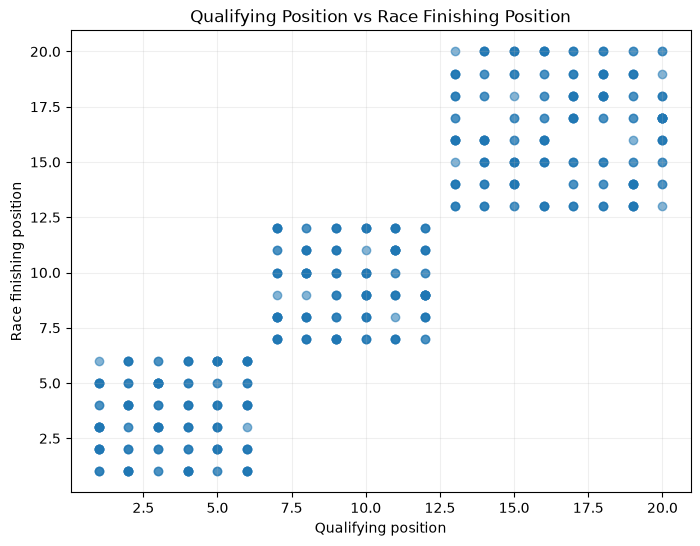

In [10]:
plt.figure(figsize=(8, 6))

plt.scatter(
    race_analysis["qualifying_position"],
    race_analysis["position"],
    alpha=0.55,
)

plt.xlabel("Qualifying position")
plt.ylabel("Race finishing position")
plt.title("Qualifying Position vs Race Finishing Position")
plt.grid(alpha=0.2)
plt.show()


### Initial observation

For the supplied 2024 data, qualifying position and finishing position have a correlation of approximately **0.89**.

That makes qualifying position an important baseline feature. At the same time, the relationship is not perfect, which leaves room for race-specific variables such as driver form, constructor strength, circuit characteristics, reliability, weather, tyre strategy, and telemetry to explain additional variation.


## 7. Positions gained or lost during the race

In [11]:
race_analysis["positions_gained"] = (
    race_analysis["qualifying_position"] - race_analysis["position"]
)

race_analysis["positions_gained"].describe()


count    480.000000
mean       0.000000
std        2.688412
min       -7.000000
25%       -2.000000
50%        0.000000
75%        2.000000
max        7.000000
Name: positions_gained, dtype: float64

In [12]:
driver_summary = (
    race_analysis
    .groupby(["driver_name", "team"], as_index=False)
    .agg(
        races=("race_id", "nunique"),
        avg_qualifying_position=("qualifying_position", "mean"),
        avg_finish_position=("position", "mean"),
        avg_positions_gained=("positions_gained", "mean"),
        total_points=("points", "sum"),
    )
    .sort_values("avg_finish_position")
)

driver_summary.head(20)


,driver_name,team,races,avg_qualifying_position,avg_finish_position,avg_positions_gained,total_points
2,Charles Leclerc,Ferrari,24,4.208333,3.125000,1.083333,377
10,Lewis Hamilton,Mercedes,24,3.500000,3.166667,0.333333,375
12,Max Verstappen,Red Bull Racing,24,3.541667,3.166667,0.375000,393
6,George Russell,Mercedes,24,3.000000,3.583333,-0.583333,342
1,Carlos Sainz,Ferrari,24,3.583333,3.916667,-0.333333,317
16,Sergio Perez,Red Bull Racing,24,3.166667,4.041667,-0.875000,308
9,Lando Norris,McLaren,24,9.375000,9.250000,0.125000,62
14,Oscar Piastri,McLaren,24,9.333333,9.291667,0.041667,64
4,Esteban Ocon,Alpine,24,9.708333,9.500000,0.208333,56
5,Fernando Alonso,Aston Martin,24,9.958333,9.500000,0.458333,48


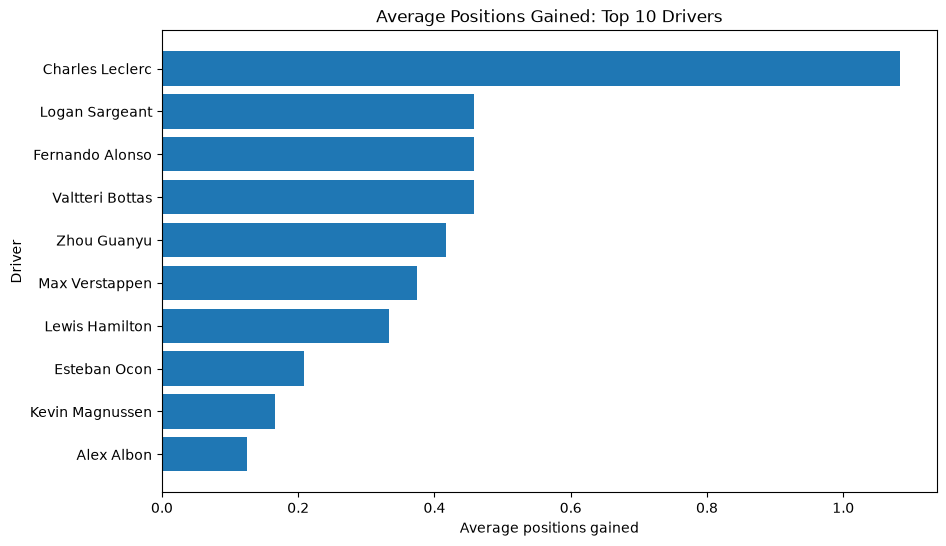

In [13]:
top_position_gainers = (
    driver_summary
    .sort_values("avg_positions_gained", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_position_gainers["driver_name"],
    top_position_gainers["avg_positions_gained"]
)
plt.xlabel("Average positions gained")
plt.ylabel("Driver")
plt.title("Average Positions Gained: Top 10 Drivers")
plt.gca().invert_yaxis()
plt.show()


`positions_gained` is a simple derived feature:

- positive value → driver finished ahead of the qualifying position
- zero → same position
- negative value → driver lost positions

For future modeling, this should be converted into a **historical / rolling feature** rather than calculated using the result of the race being predicted.


## 8. Constructor performance

In [14]:
constructor_summary = (
    race_analysis
    .groupby("team", as_index=False)
    .agg(
        avg_qualifying_position=("qualifying_position", "mean"),
        avg_finish_position=("position", "mean"),
        avg_positions_gained=("positions_gained", "mean"),
        total_points=("points", "sum"),
    )
    .sort_values("avg_finish_position")
)

constructor_summary


,team,avg_qualifying_position,avg_finish_position,avg_positions_gained,total_points
6,Mercedes,3.250000,3.375000,-0.125000,717
2,Ferrari,3.895833,3.520833,0.375000,694
8,Red Bull Racing,3.354167,3.604167,-0.250000,701
5,McLaren,9.354167,9.270833,0.083333,126
0,Alpine,9.437500,9.583333,-0.145833,99
1,Aston Martin,9.708333,9.645833,0.062500,87
4,Kick Sauber,16.395833,15.958333,0.437500,0
3,Haas,15.958333,16.250000,-0.291667,0
9,Williams,16.791667,16.500000,0.291667,0
7,RB,16.854167,17.291667,-0.437500,0


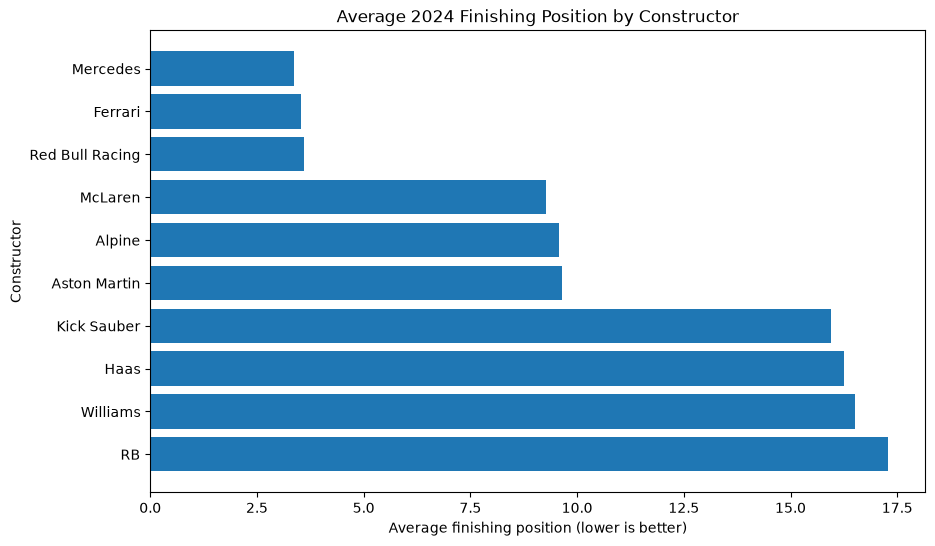

In [15]:
plt.figure(figsize=(10, 6))
plt.barh(
    constructor_summary["team"],
    constructor_summary["avg_finish_position"]
)
plt.xlabel("Average finishing position (lower is better)")
plt.ylabel("Constructor")
plt.title("Average 2024 Finishing Position by Constructor")
plt.gca().invert_yaxis()
plt.show()


## 9. Circuit metadata

In [16]:
circuits = datasets["f1_circuits_metadata"]

display(circuits.head())
display(
    circuits[
        [
            "circuit_length_km",
            "total_laps",
            "number_of_turns",
            "drs_zones",
            "elevation_change_m",
            "race_distance_km",
        ]
    ].describe()
)


,circuit_name,city,country,circuit_length_km,total_laps,number_of_turns,lap_record,lap_record_holder,lap_record_year,drs_zones,first_f1_race,circuit_type,elevation_change_m,race_distance_km
0,Bahrain International Circuit,Sakhir,Bahrain,5.412,57,15,1:31.447,Lewis Hamilton,2020,3,2004,Permanent Circuit,44,308.48
1,Jeddah Corniche Circuit,Jeddah,Saudi Arabia,6.174,50,27,1:30.734,Lewis Hamilton,2021,3,2021,Permanent Circuit,20,308.70
2,Albert Park Circuit,Melbourne,Australia,5.278,58,16,1:20.260,Charles Leclerc,2022,2,1996,Permanent Circuit,51,306.12
3,Suzuka International Racing Course,Suzuka,Japan,5.807,53,18,1:30.983,Lewis Hamilton,2019,2,1987,Permanent Circuit,48,307.77
4,Shanghai International Circuit,Shanghai,China,5.451,56,16,1:32.238,Michael Schumacher,2004,2,2004,Permanent Circuit,26,305.26


,circuit_length_km,total_laps,number_of_turns,drs_zones,elevation_change_m,race_distance_km
count,24.000000,24.000000,24.000000,24.000000,24.00000,24.000000
mean,5.189792,60.208333,17.125000,1.750000,34.50000,305.420833
std,0.829905,8.949030,3.663124,0.793999,14.79718,9.713293
min,3.337000,44.000000,10.000000,0.000000,9.00000,260.290000
25%,4.376000,53.000000,15.000000,1.000000,23.75000,306.142500
50%,5.346500,57.500000,16.500000,2.000000,31.50000,306.850000
75%,5.796500,70.000000,19.000000,2.000000,49.50000,308.587500
max,7.004000,78.000000,27.000000,3.000000,57.00000,310.050000


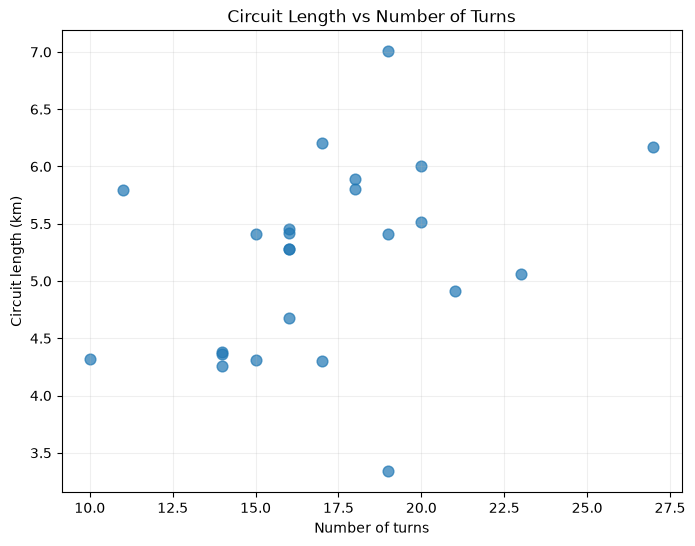

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(
    circuits["number_of_turns"],
    circuits["circuit_length_km"],
    s=60,
    alpha=0.7,
)

plt.xlabel("Number of turns")
plt.ylabel("Circuit length (km)")
plt.title("Circuit Length vs Number of Turns")
plt.grid(alpha=0.2)
plt.show()


Circuit metadata is especially valuable for the intended interactive simulator because it gives us track-level context that can be joined to race and driver performance.

Candidate circuit features include:

- circuit length
- number of turns
- DRS zones
- elevation change
- circuit type
- race distance


## 10. Driver standings and constructor standings

In [18]:
driver_standings = datasets["f1_2024_driver_standings"]
constructor_standings = datasets["f1_2024_constructor_standings"]

display(driver_standings.head())
display(constructor_standings.head())


,race_round,position,driver_name,team,nationality,total_points,wins,podiums,pole_positions,fastest_laps,dnfs,races_completed,points_per_race
0,1,1,Max Verstappen,Red Bull Racing,NED,25,1,1,1,0,0,1,25.0
1,1,2,Lewis Hamilton,Mercedes,GBR,18,0,1,0,0,0,1,18.0
2,1,3,Carlos Sainz,Ferrari,ESP,15,0,1,0,0,0,1,15.0
3,1,4,Sergio Perez,Red Bull Racing,MEX,12,0,0,0,1,0,1,12.0
4,1,5,George Russell,Mercedes,GBR,10,0,0,0,0,0,1,10.0


,race_round,position,constructor,engine,team_principal,driver_lineup,total_points,wins,podiums,pole_positions,fastest_laps,dnfs,races_entered
0,1,1,Red Bull Racing,Honda RBPT,Christian Horner,Max Verstappen / Sergio Perez,37,1,1,1,1,0,2
1,1,2,Mercedes,Mercedes,Toto Wolff,Lewis Hamilton / George Russell,28,0,1,0,0,0,2
2,1,3,Ferrari,Ferrari,Frederic Vasseur,Carlos Sainz / Charles Leclerc,23,0,1,0,0,0,2
3,1,4,Alpine,Renault,Bruno Famin,Pierre Gasly / Esteban Ocon,6,0,0,0,0,0,2
4,1,5,McLaren,Mercedes,Andrea Stella,Oscar Piastri / Lando Norris,5,0,0,0,0,0,2


These standings tables can support useful **pre-race form features**, but they must be handled carefully.

For a race in round `r`, the model should only use standings information from **before round `r`**. Using end-of-race or end-of-season totals to predict an earlier race would introduce **target leakage**.


## 11. Simple leakage audit

In [19]:
possible_post_race_columns = [
    "position",
    "race_time",
    "points",
    "fastest_lap",
]

print("Columns that describe the result of the race itself:")
for column in possible_post_race_columns:
    if column in race.columns:
        print(" -", column)


Columns that describe the result of the race itself:
 - position
 - race_time
 - points
 - fastest_lap


### Why leakage matters

The goal of the future simulator is to predict a race *before* the result is known.

Therefore, a modeling row for each driver/race should contain only information that would have been available at the chosen prediction time.

For example:

**Safe candidate features**
- previous-race form
- previous championship standings
- qualifying position
- circuit characteristics
- pre-race weather
- historical reliability

**Unsafe if predicting the same race**
- final finishing position
- points earned in that race
- race fastest-lap flag
- final race time
- standings updated using that race result

This distinction will be central to the modeling pipeline.


## 12. Initial findings and next steps

### Initial findings

1. The current repository contains complementary race, qualifying, standings, driver, and circuit datasets.
2. Race and qualifying tables can be joined cleanly using `race_id` and `driver_name`.
3. Qualifying position is strongly related to finishing position and is therefore an important baseline predictor.
4. Positions gained/lost provides an intuitive way to study performance relative to starting position.
5. Circuit metadata provides useful context for track-specific modeling.
6. Q2/Q3 missing values are largely structural and should be treated carefully rather than blindly imputed.
7. The largest modeling challenge will be creating **time-correct, leakage-safe pre-race features**.

### Next steps

- convert qualifying-time strings into numeric seconds
- construct rolling driver-form features
- construct rolling constructor-form and reliability features
- join circuit metadata into the modeling table
- define a baseline target (finish position / ranking)
- build a simple baseline model
- evaluate ranking-oriented metrics
- add weather data
- investigate lap-by-lap and telemetry data
- develop the interactive simulation layer
